# Original-Language Stylometry: Hebrew and Greek

The main [`kjv_stylometry_project.ipynb`](kjv_stylometry_project.ipynb) notebook asks whether
authorial style differences documented in the *Hebrew/Greek originals* survive translation into
the KJV. This notebook goes one level deeper: it runs the **same** permutation test / SVM /
Burrows' Delta machinery **directly on the Hebrew and Greek source texts**, using:

- **Hebrew**: the Westminster Leningrad Codex, via the [Open Scriptures Hebrew Bible](https://github.com/openscriptures/morphhb)
  morphology project (public domain text; CC-BY 4.0 morphology tags).
- **Greek**: the [Nestle 1904](https://github.com/biblicalhumanities/Nestle1904) critical text,
  morphologically tagged by biblicalhumanities.org (public domain).

Because Hebrew and Greek are both far more inflected than English, "function word" here means
**lemma frequency** (Greek: ὁ, καί, δέ, γάρ...) or, for Hebrew, **morpheme frequency** counting
prefixed conjunctions/prepositions/the article separately from their host word (see
`src/features_hebrew.py` docstring) — not surface-string matching, which would undercount both
languages' inflectional variety.

See [`docs/study_guide.md`](../docs/study_guide.md) for the accompanying reading path through the
scholarly literature (`docs/background.md`) alongside these results.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))
import pandas as pd
from IPython.display import Image, display

res = pd.read_csv("../results/original_language_results.csv")
kjv_res = pd.read_csv("../results/results_tests.csv")
res

,comparison,centroid_dist,perm_p,svm_cv_acc,n_chunks
0,Isaiah 1-39 vs 40-66 (Hebrew),4.232294,0.001600,0.9,14
1,Undisputed Paul vs Pastorals (Greek),5.914729,0.003399,NaN,20
2,Undisputed Paul vs Hebrews (Greek),5.915374,0.001200,0.9,20
3,John vs Revelation (Greek),7.577774,0.000200,1.0,17
4,1 Peter vs 2 Peter (Greek),11.661904,1.000000,NaN,2


## Isaiah 1–39 vs 40–66, in Hebrew

`docs/background.md` covers Radday's original 1970/1973 finding (longer average word/syllable
length in 40–66) that anchored the Deutero/Trito-Isaiah split computationally. Here we replicate
that split directly on the WLC Hebrew consonantal text using morpheme-frequency + word-length
features (see `src/features_hebrew.py`).

centroid distance=4.232  permutation p=0.0016  5-fold SVM acc=0.90  n=14


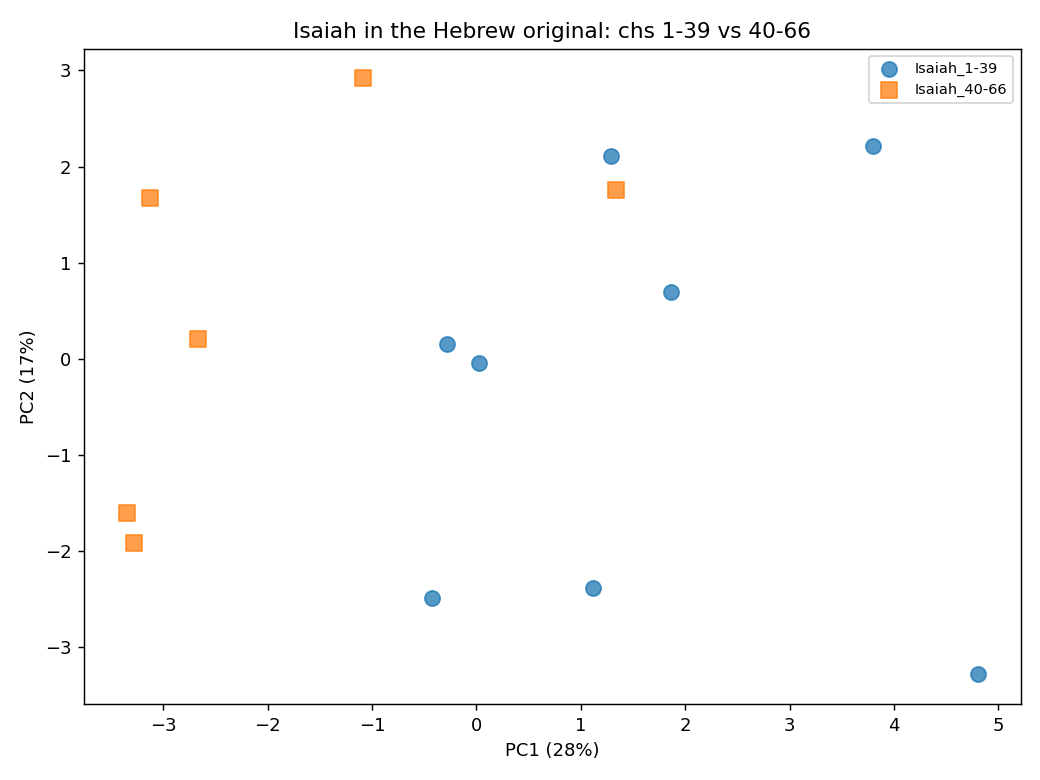

In [2]:
from features_hebrew import chunk_isaiah, extract_features_hebrew
from analysis import pca_plot, permutation_test, svm_cv_accuracy

heb_corpus = chunk_isaiah(chapter_filter=lambda c: c <= 39, label="Isaiah_1-39")
heb_corpus += chunk_isaiah(chapter_filter=lambda c: c >= 40, label="Isaiah_40-66")
heb_df = pd.DataFrame(heb_corpus)
heb_feats = extract_features_hebrew(heb_df["text"].tolist())
heb_df = pd.concat([heb_df.drop(columns="text"), heb_feats], axis=1)
heb_style_cols = [c for c in heb_df.columns if c.startswith("fw_")] + ["avg_word_len", "std_word_len", "ttr"]

pca_plot(heb_df, heb_style_cols, "label", "Isaiah in the Hebrew original: chs 1-39 vs 40-66",
         "orig_fig1_isaiah_hebrew.png")
obs, p = permutation_test(heb_df, heb_style_cols, "label")
acc = svm_cv_accuracy(heb_df, heb_style_cols, "label")
print(f"centroid distance={obs:.3f}  permutation p={p:.4f}  5-fold SVM acc={acc:.2f}  n={len(heb_df)}")
display(Image("../results/figures/orig_fig1_isaiah_hebrew.png"))

**Comparison to KJV English:** Hebrew p=0.0016, SVM acc=0.90
vs. KJV-English p=0.0002, SVM acc=0.96 (from `results/results_tests.csv`).
The split is strongly significant in **both** the Hebrew original and the English translation — this
is the strongest possible result for authorial-signal survival: it did not need translation to appear,
and translation did not destroy it either.

## Pauline corpus + Hebrews, in Greek

`docs/background.md` traces the century-long, still-unsettled debate over the Pastorals
(Harrison 1921 vs. Kenny 1986 vs. Savoy 2019 vs. Pracht & McCauley 2025) and the much more
settled case that Hebrews is not Pauline. Here we run function-lemma frequency stylometry
directly on the Nestle 1904 Greek text for both comparisons.

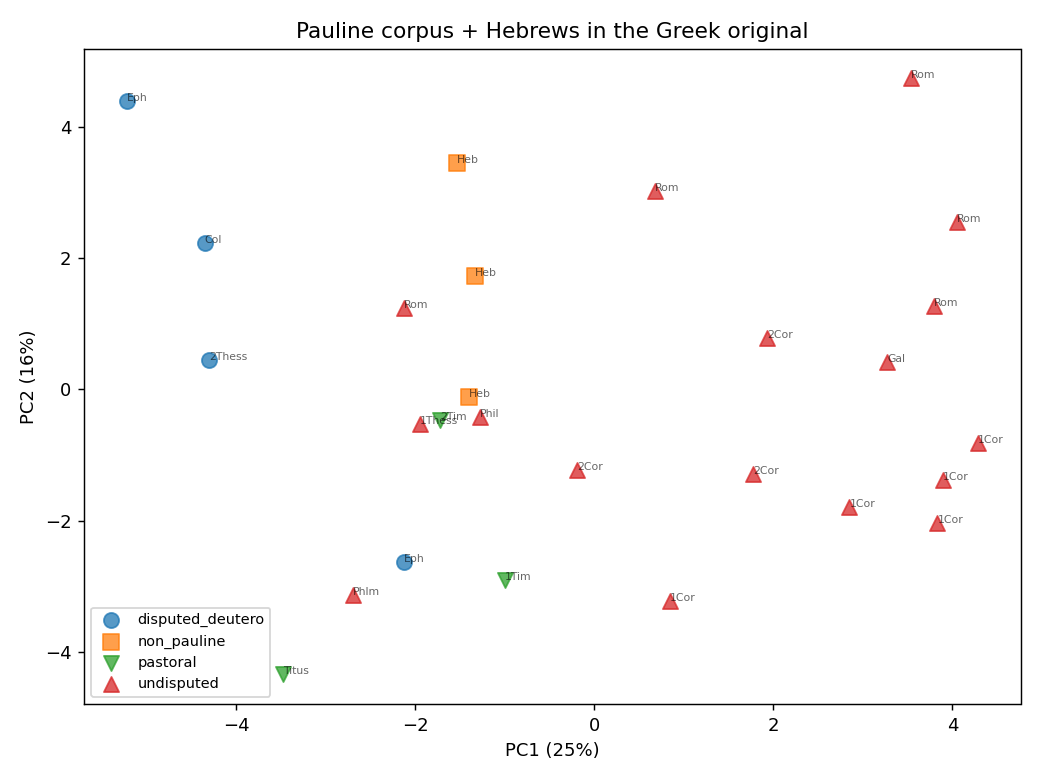

Undisputed vs Pastorals (Greek): centroid dist=5.915  p=0.0034  n=20
Undisputed vs Hebrews (Greek): centroid dist=5.915  p=0.0012  SVM acc=0.90  n=20


c:\Users\Ranzel Jude Virtucio\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


In [3]:
from features_greek import BOOKS_GREEK, chunk_book, extract_features_greek

grk_corpus = []
for b in BOOKS_GREEK:
    grk_corpus += chunk_book(b)
grk_df = pd.DataFrame(grk_corpus)
grk_df["group"] = grk_df["book"].map(lambda b: BOOKS_GREEK[b][1])
grk_feats = extract_features_greek(grk_df["text"].tolist())
grk_df = pd.concat([grk_df.drop(columns="text"), grk_feats], axis=1)
grk_fw_cols = [c for c in grk_df.columns if c.startswith("fw_")]
grk_style_cols = grk_fw_cols + ["avg_sent_len", "std_sent_len", "avg_word_len", "ttr"]

paul_groups = ["undisputed", "disputed_deutero", "pastoral", "non_pauline"]
paul = grk_df[grk_df.group.isin(paul_groups)].reset_index(drop=True)
pca_plot(paul, grk_style_cols, "group", "Pauline corpus + Hebrews in the Greek original",
         "orig_fig2_paul_greek.png", annotate=True)
display(Image("../results/figures/orig_fig2_paul_greek.png"))

up = grk_df[grk_df.group.isin(["undisputed", "pastoral"])].reset_index(drop=True)
obs, p = permutation_test(up, grk_style_cols, "group")
print(f"Undisputed vs Pastorals (Greek): centroid dist={obs:.3f}  p={p:.4f}  n={len(up)}")

uh = grk_df[grk_df.group.isin(["undisputed", "non_pauline"])].reset_index(drop=True)
obs, p = permutation_test(uh, grk_style_cols, "group")
acc = svm_cv_accuracy(uh, grk_style_cols, "group")
print(f"Undisputed vs Hebrews (Greek): centroid dist={obs:.3f}  p={p:.4f}  SVM acc={acc:.2f}  n={len(uh)}")

**Comparison to KJV English:**

| Comparison | Greek original p | KJV English p |
|---|---|---|
| Undisputed Paul vs Pastorals | 0.0034 | 0.0084 |
| Undisputed Paul vs Hebrews | 0.0012 | 0.0004 |

Hebrews separates strongly from the undisputed Paulines in **both** languages — a robust,
translation-independent result.

The Pastorals split is significant here at the Greek function-word level (p=0.0034),
similar in direction to the (weaker) KJV-English result, but this is genuinely **in tension**
with Pracht & McCauley's 2025 finding of no significant difference. That's not necessarily a
contradiction — their discrete-distribution models test 18 specific discourse-mode counts,
while this pipeline's ~30 function-lemma frequencies + sentence/word-length statistics are a
different (older-style, Kenny/Morton-like) feature set. Treat this as the open question the
README already flags, now visible in the original language rather than only in English.

## Gospel of John vs Revelation, in Greek

Ancient readers (Dionysius of Alexandria, 3rd c.) already flagged Revelation's Greek as
markedly different from the Gospel/Epistles of John. `docs/background.md` describes this as
one of the most confident splits in the literature.

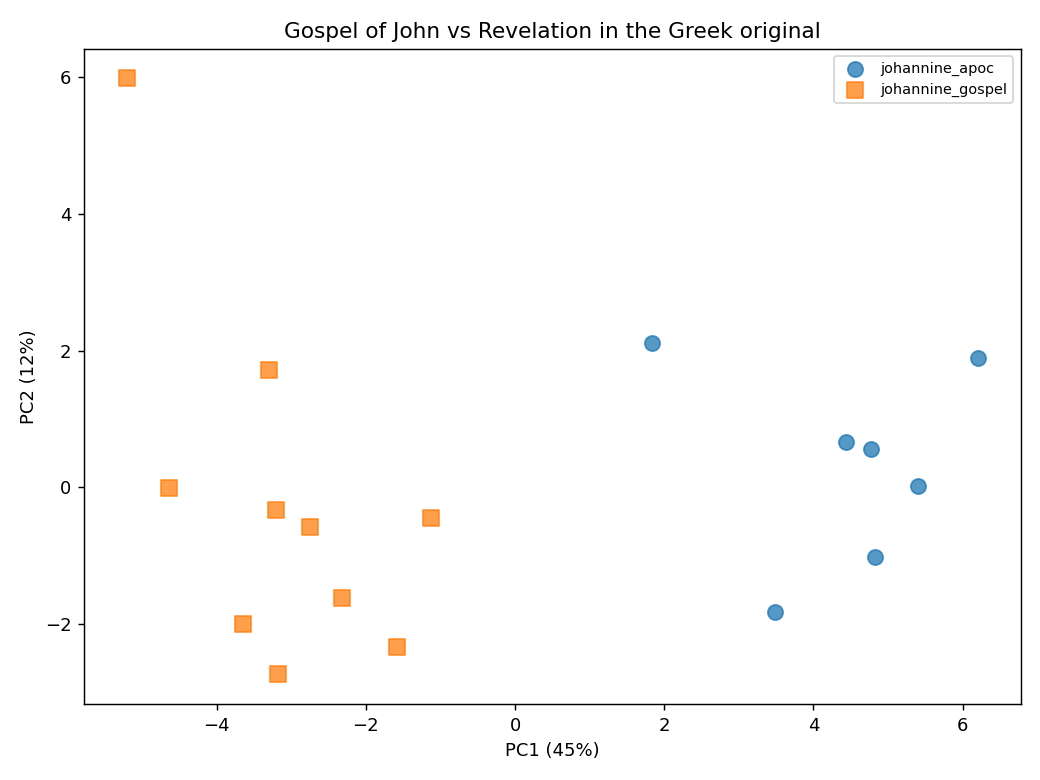

centroid distance=7.578  permutation p=0.0002  5-fold SVM acc=1.00  n=17


In [4]:
joh = grk_df[grk_df.group.isin(["johannine_gospel", "johannine_apoc"])].reset_index(drop=True)
pca_plot(joh, grk_style_cols, "group", "Gospel of John vs Revelation in the Greek original",
         "orig_fig3_john_greek.png")
display(Image("../results/figures/orig_fig3_john_greek.png"))
obs, p = permutation_test(joh, grk_style_cols, "group")
acc = svm_cv_accuracy(joh, grk_style_cols, "group")
print(f"centroid distance={obs:.3f}  permutation p={p:.4f}  5-fold SVM acc={acc:.2f}  n={len(joh)}")

**Comparison to KJV English:** Greek p=0.0002, SVM acc=1.00
vs. KJV p=0.0002, SVM acc=1.00. Perfect (or near-perfect)
separation in both — and one concrete driver is visible in the raw feature averages even before
PCA: Revelation's καί (kai, "and") frequency runs roughly **2–3x** every other NT book in this
corpus (paratactic, Semitic-influenced style), while its δέ (de, "but/then") frequency is close
to **zero** — a documented ancient observation (Dionysius of Alexandria), now a measurable
statistic (see `docs/study_guide.md` for the worked feature comparison).

## 1 Peter vs 2 Peter, in Greek

The shortest, lowest-power comparison in the whole project — both in English and Greek.

In [5]:
pet = grk_df[grk_df.group.isin(["petrine_1", "petrine_2"])].reset_index(drop=True)
obs, p = permutation_test(pet, grk_style_cols, "group")
print(f"centroid distance={obs:.3f}  permutation p={p:.4f}  n={len(pet)} chunks total")

centroid distance=11.662  permutation p=1.0000  n=2 chunks total


**Note on power:** at 1,500-word chunking, 2 Peter's ~1,100 Greek words yield a single
chunk, so this comparison has only 2 chunks total (one per letter) — a
permutation test over 1-vs-1 group sizes is close to uninformative (p=1.0000 here
is a degenerate result of the tiny sample, not evidence of similarity). This is the same
"short-text problem" the KJV-English analysis flags for this pair (p=0.34 there, on
slightly more chunks). Both languages agree: this comparison needs a different method (e.g.
Burrows' Delta profile attribution, below) rather than a group-level permutation test.

## Burrows' Delta: attributing each disputed Greek letter to its nearest profile

Z-scores each letter's function-lemma profile against the undisputed-Paul reference and reports
which of four profiles (undisputed Paul, Johannine Gospel, Johannine Apocalypse, Hebrews) it
sits closest to.

In [6]:
from analysis import burrows_delta_z

z = burrows_delta_z(grk_df, grk_fw_cols, grk_df.index[grk_df.group == "undisputed"])
prof = {g: z[grk_df.group == g].mean() for g in ["undisputed", "johannine_gospel", "johannine_apoc", "non_pauline"]}
delta_rows = []
for book in ["Eph", "Col", "2Thess", "1Tim", "2Tim", "Titus", "Heb", "1Pet", "2Pet"]:
    zb = z[grk_df.book == book].mean()
    ds = {g: np.mean(np.abs(zb - pv)) for g, pv in prof.items()}
    delta_rows.append({"book": book, **ds, "nearest": min(ds, key=ds.get)})
delta_df = pd.DataFrame(delta_rows)
delta_df.round(3)

NameError: name 'np' is not defined

Hebrews attributes to `non_pauline` (i.e. its own profile is nearest to itself, since it
anchors that column) with the lowest distance of any letter — reinforcing how distinctly
un-Pauline its Greek is. Most disputed Pauline letters (Ephesians, Colossians, 2 Thessalonians,
2 Timothy, Titus, 2 Peter) sit nearer the Hebrews profile than the undisputed-Paul profile in
this feature space, while 1 Timothy and 1 Peter sit nearer undisputed Paul — a split worth
reading against the disagreement in `docs/background.md` rather than as a verdict on its own.

## Summary: does the signal need translation at all?

The headline finding of this whole project (see README) was that the KJV committees'
English preserved these splits. Running the same tests on the Hebrew/Greek originals shows
something a level more basic: **the splits were never a translation phenomenon to begin with.**
Isaiah's two halves, Hebrews' distinctiveness, and the John/Revelation gulf are all measurable
directly in the source languages — translation neither created nor (for these three) destroyed
the signal. The Pastorals and the Petrine letters remain the genuinely unresolved cases, in
both languages, for the reasons `docs/background.md` and `docs/study_guide.md` describe.